In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
pd.set_option('display.max_columns', 500)
import contextily as ctx

In [2]:
df = pd.read_csv('../data/data1.csv', sep = ';')

In [3]:
powiaty = gpd.read_file('../data/powiaty.shp')

In [4]:
dzielnice = gpd.read_file('../data/dzielnice_Warszawy.shp')

In [5]:
geometry = [Point(lon, lat) for lon, lat in zip(df['lon'], df['lat'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

In [6]:
powiaty = powiaty.to_crs(gdf.crs)
dzielnice = dzielnice.to_crs(gdf.crs)

In [7]:
spatial_join_powiaty = gpd.sjoin(powiaty, gdf, how='inner', op='contains')

C:\Users\Filip\AppData\Roaming\Python\Python312\site-packages\IPython\core\interactiveshell.py:3517: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


In [8]:
powiaty_maz = spatial_join_powiaty[['JPT_NAZWA_', 'geometry']]


In [9]:
powiaty_maz

,JPT_NAZWA_,geometry
2,powiat ostrołęcki,"POLYGON ((21.20011 53.39916, 21.20178 53.40052..."
2,powiat ostrołęcki,"POLYGON ((21.20011 53.39916, 21.20178 53.40052..."
2,powiat ostrołęcki,"POLYGON ((21.20011 53.39916, 21.20178 53.40052..."
2,powiat ostrołęcki,"POLYGON ((21.20011 53.39916, 21.20178 53.40052..."
2,powiat ostrołęcki,"POLYGON ((21.20011 53.39916, 21.20178 53.40052..."
...,...,...
368,powiat Płock,"POLYGON ((19.69555 52.47374, 19.69474 52.47403..."
368,powiat Płock,"POLYGON ((19.69555 52.47374, 19.69474 52.47403..."
368,powiat Płock,"POLYGON ((19.69555 52.47374, 19.69474 52.47403..."
368,powiat Płock,"POLYGON ((19.69555 52.47374, 19.69474 52.47403..."


In [10]:
powiaty_maz = powiaty_maz.drop_duplicates(subset='JPT_NAZWA_')

<Axes: >

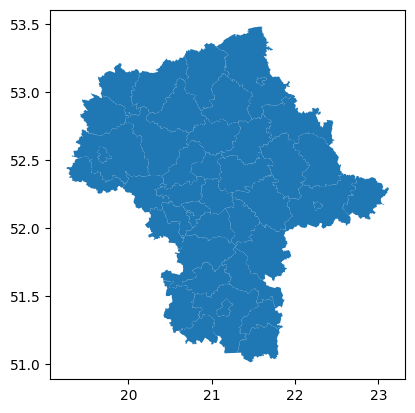

In [11]:
powiaty_maz.plot()

In [12]:
warsaw = gpd.sjoin(gdf, dzielnice,  how='inner', op='within')

C:\Users\Filip\AppData\Roaming\Python\Python312\site-packages\IPython\core\interactiveshell.py:3517: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


In [13]:
kod_tech = pd.read_csv("../data/lista high tech.csv", sep = ";")

In [14]:
pop_point = pd.read_csv("../data/points_popul_maz.csv", sep = ",")

In [16]:
gdf_ht = gdf[gdf['if_hightech'] == 1]

In [17]:
import pickle

with open('../data/gdf_ht.pickle', 'wb') as file:
    pickle.dump(gdf_ht, file)

In [18]:
import pickle

with open('../data/gdf.pickle', 'wb') as file:
    pickle.dump(gdf, file)

In [19]:
with open('../data/warsaw.pickle', 'wb') as file:
    pickle.dump(warsaw, file)

In [20]:
with open('../data/dzielnice.pickle', 'wb') as file:
    pickle.dump(dzielnice, file)

In [21]:
with open('../data/powiaty_maz.pickle', 'wb') as file:
    pickle.dump(powiaty_maz, file)